In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import random
import numpy as np

In [2]:
from Bio import SeqIO
from Bio.Seq import Seq

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from akita_model.model import SeqNN

In [4]:
# 100 strongest CTCFs
ctcf_df = pd.read_csv("/scratch1/smaruj/full_akita_vs_semifreddo/top100_ctcfs.csv")

In [5]:
from pyfaidx import Fasta

In [6]:
genome = Fasta("/project2/fudenber_735/genomes/mm10/mm10.fa")

In [7]:
def get_ctcf_forward_seq(chrom, start, end, strand, genome_path):
    seq = genome[chrom][start:end].seq
    if strand == "-":
        # reverse complement
        complement = str.maketrans("ACGTacgt", "TGCAtgca")
        seq = seq[::-1].translate(complement)
    return seq.upper()

In [9]:
# Apply to all 100 CTCFs
ctcf_df["ctcf_seq"] = ctcf_df.apply(
    lambda row: get_ctcf_forward_seq(row["chrom"], row["start"], row["end"], row["strand"]), axis=1
)

In [10]:
ctcf_df = ctcf_df[:2]

In [11]:
ctcf_df

,seq_id,chrom,start,end,strand,SCD_tg0,ctcf_seq
0,2956,chr7,37357852,37357871,-,65.40312,TGGCCACAAGAGGGCACTC
1,6097,chr14,87452272,87452291,-,63.08750,AGACCACAAGATGGCAGCA


In [12]:
def one_hot_encode(sequence, return_type='numpy', channels_first=False):
    """
    One-hot encode a DNA sequence for Akita input
    
    Parameters:
    -----------
    sequence : str
        DNA sequence string
    return_type : str
        'numpy' or 'torch' - type of array to return
    channels_first : bool
        If True, return shape (4, length) for PyTorch conv layers
        If False, return shape (length, 4)
    
    Returns:
    --------
    np.array or torch.Tensor : One-hot encoded sequence
                                If channels_first=False: (length, 4)
                                If channels_first=True: (4, length)
                                Order: A, C, G, T
    """
    # Mapping for one-hot encoding
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3,
               'a': 0, 'c': 1, 'g': 2, 't': 3,
               'N': -1, 'n': -1}  # Handle N bases
    
    # Initialize array
    seq_len = len(sequence)
    one_hot = np.zeros((seq_len, 4), dtype=np.float32)
    
    # Fill in one-hot encoding
    for i, base in enumerate(sequence):
        if base in mapping:
            idx = mapping[base]
            if idx >= 0:  # Skip N bases
                one_hot[i, idx] = 1.0
            else:  # For N, use uniform distribution
                one_hot[i, :] = 0.25
    
    # Transpose if channels_first
    if channels_first:
        one_hot = one_hot.T  # Shape: (4, length)
    
    if return_type == 'torch':
        import torch
        return torch.from_numpy(one_hot)
    else:
        return one_hot

In [13]:
def reverse_complement(seq):
    """Get reverse complement of a DNA sequence"""
    return str(Seq(seq).reverse_complement())

In [14]:
def insert_ctcfs_at_positions(background_seq, ctcf_seq, ctcf_orientations, ctcf_positions):
    """
    Insert CTCFs at specified positions with given orientations
    
    Parameters:
    -----------
    background_seq : str
        Background DNA sequence
    ctcf_seq : str
        CTCF motif sequence
    ctcf_orientations : list
        List of orientations for each CTCF ('forward' or 'reverse')
    ctcf_positions : list
        List of positions (in bp) where to insert each CTCF
    
    Returns:
    --------
    str : Modified sequence with CTCFs inserted
    """
    seq_list = list(background_seq)
    
    insertions = []
    for pos, orientation in zip(ctcf_positions, ctcf_orientations):
        if orientation == 'reverse':
            seq_to_insert = reverse_complement(ctcf_seq)
        else:
            seq_to_insert = ctcf_seq
        insertions.append((pos, seq_to_insert))
    
    # Sort by position (descending) to insert from right to left
    insertions.sort(key=lambda x: x[0], reverse=True)
    
    # Insert CTCFs by replacement
    for pos, seq_to_insert in insertions:
        for i, base in enumerate(seq_to_insert):
            if pos + i < len(seq_list):
                seq_list[pos + i] = base
    
    return ''.join(seq_list)



In [15]:
def calculate_ctcf_positions_new_design(background_length, outer_span_kb=400, 
                                        middle_config="", middle_separation_bp=250,
                                        outer_config="><"):
    """
    Calculate CTCF positions for new experimental design
    
    Parameters:
    -----------
    background_length : int
        Length of background sequence in bp
    outer_span_kb : int
        Span from CTCF1 to CTCF4 in kilobases (default: 400kb)
    middle_config : str
        Configuration of middle CTCFs, e.g., "", "<", "<<", "<<<", "<<<<", "<>", "><>", "><><"
        Empty string means no middle CTCFs
    middle_separation_bp : int
        Separation between adjacent middle CTCFs in bp (default: 250bp)
    outer_config : str
        Configuration of outer CTCFs (2 characters), e.g., "><", ">>", "<<", "<>"
        First char = CTCF1, Second char = CTCF4
        Default: "><" (divergent)
    
    Returns:
    --------
    list : Positions for all CTCFs
    list : Orientations for all CTCFs
    str : Description of configuration
    """
    if len(outer_config) != 2:
        raise ValueError("outer_config must be exactly 2 characters (e.g., '><', '>>', '<<', '<>')")
    
    middle_pos = background_length // 2
    outer_span_bp = outer_span_kb * 1000
    
    # Outer CTCFs at fixed positions
    ctcf1_pos = middle_pos - (outer_span_bp // 2)
    ctcf4_pos = middle_pos + (outer_span_bp // 2)
    
    # Parse outer orientations
    ctcf1_orientation = 'forward' if outer_config[0] == '>' else 'reverse'
    ctcf4_orientation = 'forward' if outer_config[1] == '>' else 'reverse'
    
    positions = [ctcf1_pos]
    orientations = [ctcf1_orientation]
    
    # Parse middle configuration
    if middle_config:
        num_middle = len(middle_config)
        
        # Calculate starting position for middle CTCFs (centered)
        total_middle_span = (num_middle - 1) * middle_separation_bp
        middle_start = middle_pos - (total_middle_span // 2)
        
        # Add middle CTCFs
        for i, symbol in enumerate(middle_config):
            pos = middle_start + (i * middle_separation_bp)
            positions.append(pos)
            orientations.append('forward' if symbol == '>' else 'reverse')
    
    # Add CTCF4
    positions.append(ctcf4_pos)
    orientations.append(ctcf4_orientation)
    
    # Create description
    num_ctcfs = len(positions)
    config_desc = f"Outer({outer_config})_Middle({middle_config if middle_config else 'none'})"
    
    return positions, orientations, config_desc


In [16]:
def create_experiment_configurations(ctcf_df, background_fasta, 
                                     outer_span_kb=400,
                                     outer_config="<<",
                                     middle_configs=["", "<<", "<<<<", "<<<<<<", 
                                                    "<>", "<><>", "<><><>"],
                                     middle_separation_bp=250,
                                     include_controls=True):
    """
    Create experiment configurations for all CTCF setups
    
    Parameters:
    -----------
    ctcf_df : pd.DataFrame
        DataFrame with CTCF information (must have 'ctcf_seq' column)
    background_fasta : str
        Path to background sequences FASTA file
    outer_span_kb : int
        Span from CTCF1 to CTCF4 in kb (default: 400)
    outer_config : str
        Configuration of outer CTCFs (2 characters), e.g., "><", ">>", "<<", "<>"
        First char = CTCF1, Second char = CTCF4
        Default: "><" (divergent - loop-forming)
        Examples:
          "><" - divergent (standard loop)
          ">>" - both forward (tandem)
          "<<" - both reverse (tandem)
          "<>" - convergent (potentially insulating)
    middle_configs : list
        List of middle CTCF configurations to test
        Examples: "", "<", "<<", "<<<", "<<<<", "<>", "><>", "><><"
    middle_separation_bp : int
        Separation between adjacent middle CTCFs in bp (default: 250)
    include_controls : bool
        If True, include control conditions (no CTCFs, outer only)
    
    Returns:
    --------
    pd.DataFrame : Experiment configuration dataframe
    dict : Background sequences {index: sequence}
    """
    # Read background sequences with simple integer indexing
    print("Loading background sequences...")
    background_seqs = {}
    for idx, record in enumerate(SeqIO.parse(background_fasta, "fasta")):
        background_seqs[idx] = str(record.seq)
        print(f"  Background {idx}: {len(record.seq):,} bp")
    
    num_backgrounds = len(background_seqs)
    print(f"Loaded {num_backgrounds} background sequences")
    
    experiments = []
    
    # Create all combinations of CTCF × Background × Configuration
    for ctcf_idx, ctcf_row in ctcf_df.iterrows():
        ctcf_id = ctcf_row.get('seq_id', f'ctcf_{ctcf_idx}')
        ctcf_seq = ctcf_row['ctcf_seq']
        
        for bg_idx in range(num_backgrounds):
            bg_seq = background_seqs[bg_idx]
            bg_length = len(bg_seq)
            
            # Control 1: No CTCFs (if requested)
            if include_controls:
                exp = {
                    'experiment_id': len(experiments),
                    'ctcf_id': ctcf_id,
                    'ctcf_index': ctcf_idx,
                    'background_idx': bg_idx,
                    'background_length': bg_length,
                    'ctcf_seq': ctcf_seq,
                    'configuration': 'CONTROL_NO_CTCF',
                    'outer_config': '',
                    'num_ctcfs': 0,
                    'num_middle_ctcfs': 0,
                    'middle_config': '',
                    'ctcf_positions': [],
                    'ctcf_orientations': [],
                    'outer_span_kb': outer_span_kb,
                    'middle_separation_bp': middle_separation_bp
                }
                experiments.append(exp)
            
            # Control 2: Outer CTCFs only (if requested)
            if include_controls:
                positions, orientations, config_desc = calculate_ctcf_positions_new_design(
                    bg_length, outer_span_kb, "", middle_separation_bp, outer_config
                )
                
                exp = {
                    'experiment_id': len(experiments),
                    'ctcf_id': ctcf_id,
                    'ctcf_index': ctcf_idx,
                    'background_idx': bg_idx,
                    'background_length': bg_length,
                    'ctcf_seq': ctcf_seq,
                    'configuration': f'CONTROL_OUTER_ONLY_{outer_config}',
                    'outer_config': outer_config,
                    'num_ctcfs': 2,
                    'num_middle_ctcfs': 0,
                    'middle_config': '',
                    'ctcf_positions': positions,
                    'ctcf_orientations': orientations,
                    'outer_span_kb': outer_span_kb,
                    'middle_separation_bp': middle_separation_bp
                }
                experiments.append(exp)
            
            # Main experiments: Different middle configurations
            for middle_config in middle_configs:
                if middle_config == "":  # Skip empty if already in controls
                    if include_controls:
                        continue
                
                positions, orientations, config_desc = calculate_ctcf_positions_new_design(
                    bg_length, outer_span_kb, middle_config, middle_separation_bp, outer_config
                )
                
                exp = {
                    'experiment_id': len(experiments),
                    'ctcf_id': ctcf_id,
                    'ctcf_index': ctcf_idx,
                    'background_idx': bg_idx,
                    'background_length': bg_length,
                    'ctcf_seq': ctcf_seq,
                    'configuration': config_desc,
                    'outer_config': outer_config,
                    'num_ctcfs': len(positions),
                    'num_middle_ctcfs': len(middle_config),
                    'middle_config': middle_config,
                    'ctcf_positions': positions,
                    'ctcf_orientations': orientations,
                    'outer_span_kb': outer_span_kb,
                    'middle_separation_bp': middle_separation_bp
                }
                
                experiments.append(exp)
    
    exp_df = pd.DataFrame(experiments)
    
    # Print summary
    print(f"\nExperiment summary:")
    print(f"  Total experiments: {len(exp_df)}")
    print(f"  CTCFs tested: {len(ctcf_df)}")
    print(f"  Backgrounds per CTCF: {num_backgrounds}")
    print(f"  Configurations per CTCF×Background: {len(middle_configs) + (2 if include_controls else 0)}")
    print(f"  Formula: {len(ctcf_df)} CTCFs × {num_backgrounds} backgrounds × {len(middle_configs) + (2 if include_controls else 0)} configs = {len(exp_df)} experiments")
    
    return exp_df, background_seqs

In [17]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth", map_location=device))
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [18]:
fasta_file = "/scratch1/smaruj/background_generation/background_sequences_scd30_totvar1300.fasta"

In [19]:
# Create experiment dataframe
print("Creating experiment configurations...")
exp_df, background_seqs = create_experiment_configurations(
        ctcf_df,
        fasta_file,
        outer_span_kb=400,
        outer_config="<<",  # Can change to ">>", "<<", "<>", etc.
        middle_configs=["<", "<<", "<<<", "<<<<", "<>", "><>", "><><"],
        middle_separation_bp=250,
        include_controls=True
    )

print(f"\nCreated {len(exp_df)} experiment configurations")
print("\nExperiment summary:")
print(exp_df[['experiment_id', 'configuration', 'num_ctcfs', 
                'num_middle_ctcfs', 'middle_config']].to_string(index=False))

Creating experiment configurations...
Loading background sequences...
  Background 0: 1,310,720 bp
  Background 1: 1,310,720 bp
  Background 2: 1,310,720 bp
  Background 3: 1,310,720 bp
  Background 4: 1,310,720 bp
  Background 5: 1,310,720 bp
  Background 6: 1,310,720 bp
  Background 7: 1,310,720 bp
  Background 8: 1,310,720 bp
  Background 9: 1,310,720 bp
Loaded 10 background sequences

Experiment summary:
  Total experiments: 180
  CTCFs tested: 2
  Backgrounds per CTCF: 10
  Configurations per CTCF×Background: 9
  Formula: 2 CTCFs × 10 backgrounds × 9 configs = 180 experiments

Created 180 experiment configurations

Experiment summary:
 experiment_id          configuration  num_ctcfs  num_middle_ctcfs middle_config
             0        CONTROL_NO_CTCF          0                 0              
             1  CONTROL_OUTER_ONLY_<<          2                 0              
             2    Outer(<<)_Middle(<)          3                 1             <
             3   Outer(<<)_M

In [20]:
exp_df = exp_df[:10]

In [21]:
import torch

In [22]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [23]:
import matplotlib.pyplot as plt


Processing experiment 1/10:
  Configuration: CONTROL_NO_CTCF
  Total CTCFs: 0
  Middle CTCFs: 0 ()
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.049094398239343404
avg outer dot score:  -0.03323167314132055


<Figure size 800x800 with 0 Axes>

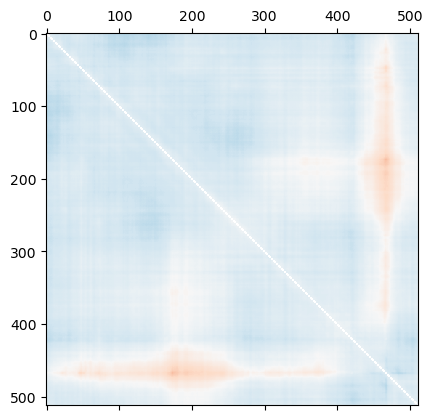


Processing experiment 2/10:
  Configuration: CONTROL_OUTER_ONLY_<<
  Total CTCFs: 2
  Middle CTCFs: 0 ()
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.07113096236925681
avg outer dot score:  0.29119396954774857


<Figure size 800x800 with 0 Axes>

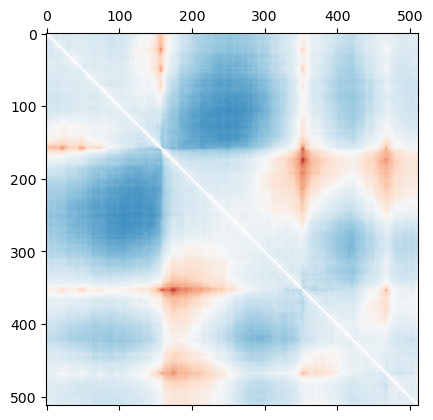


Processing experiment 3/10:
  Configuration: Outer(<<)_Middle(<)
  Total CTCFs: 3
  Middle CTCFs: 1 (<)
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.19860517469252456
avg outer dot score:  -0.13715619469682375


<Figure size 800x800 with 0 Axes>

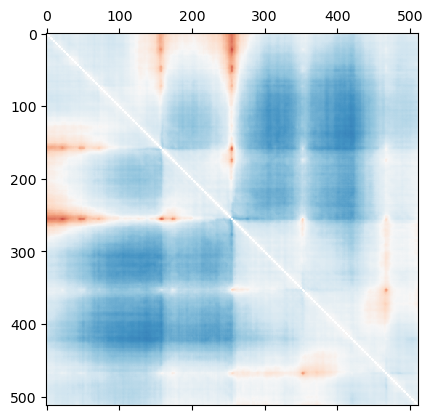


Processing experiment 4/10:
  Configuration: Outer(<<)_Middle(<<)
  Total CTCFs: 4
  Middle CTCFs: 2 (<<)
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.15154535932740804
avg outer dot score:  0.028510630130767822


<Figure size 800x800 with 0 Axes>

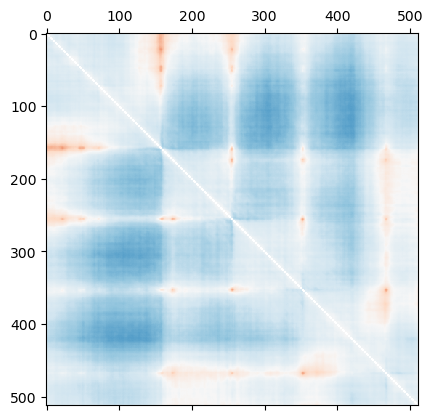


Processing experiment 5/10:
  Configuration: Outer(<<)_Middle(<<<)
  Total CTCFs: 5
  Middle CTCFs: 3 (<<<)
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.19213575983930617
avg outer dot score:  -0.11833856130639712


<Figure size 800x800 with 0 Axes>

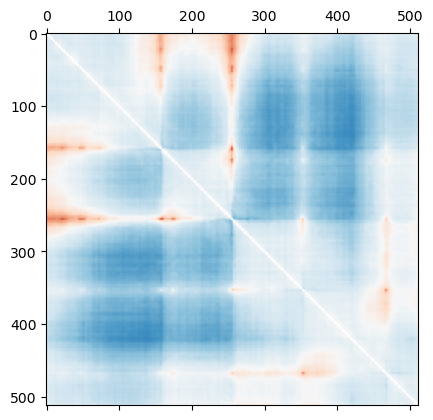


Processing experiment 6/10:
  Configuration: Outer(<<)_Middle(<<<<)
  Total CTCFs: 6
  Middle CTCFs: 4 (<<<<)
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.2056437101303517
avg outer dot score:  -0.15795923148592314


<Figure size 800x800 with 0 Axes>

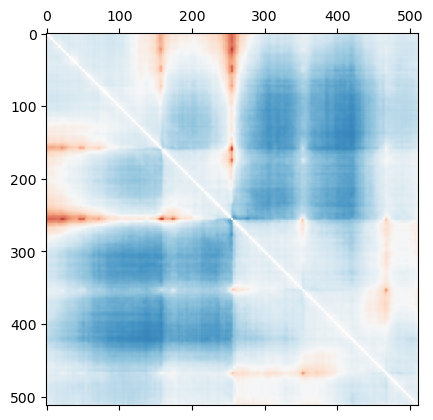


Processing experiment 7/10:
  Configuration: Outer(<<)_Middle(<>)
  Total CTCFs: 4
  Middle CTCFs: 2 (<>)
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.129073547423136
avg outer dot score:  0.10303644339243571


<Figure size 800x800 with 0 Axes>

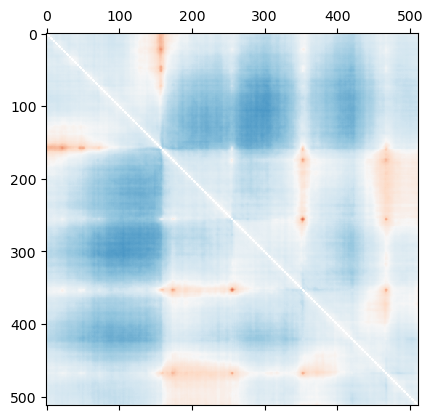


Processing experiment 8/10:
  Configuration: Outer(<<)_Middle(><>)
  Total CTCFs: 5
  Middle CTCFs: 3 (><>)
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.20777768700953397
avg outer dot score:  -0.18296300868193308


<Figure size 800x800 with 0 Axes>

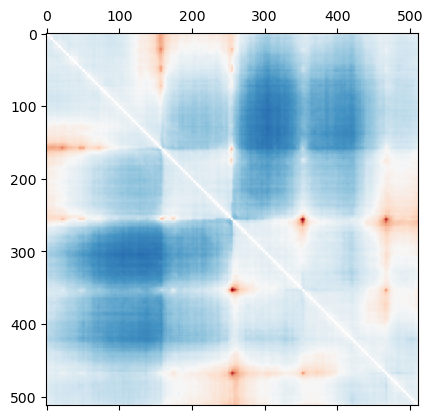


Processing experiment 9/10:
  Configuration: Outer(<<)_Middle(><><)
  Total CTCFs: 6
  Middle CTCFs: 4 (><><)
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.16223392779524978
avg outer dot score:  -0.02014961342016856


<Figure size 800x800 with 0 Axes>

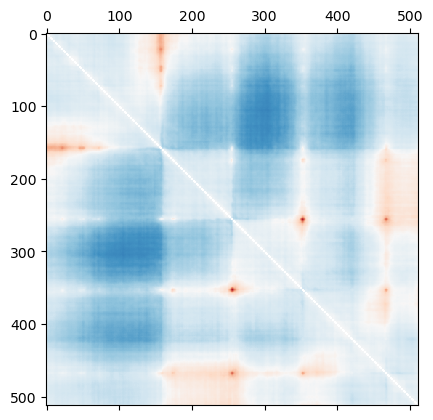


Processing experiment 10/10:
  Configuration: CONTROL_NO_CTCF
  Total CTCFs: 0
  Middle CTCFs: 0 ()
  Input shape: torch.Size([1, 4, 1310720])
avg insulation:  -0.06874417485436904
avg outer dot score:  -0.03133820494016012


<Figure size 800x800 with 0 Axes>

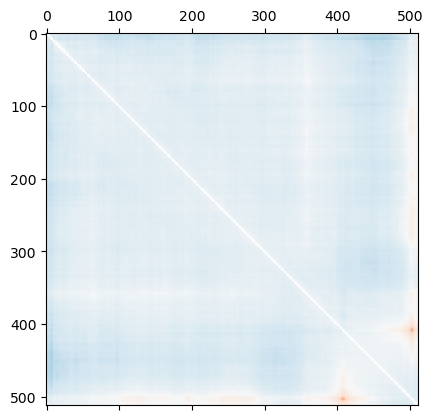

In [24]:
predictions = []
# contact_stats = []
    
for idx, row in exp_df.iterrows():
    print(f"\nProcessing experiment {idx+1}/{len(exp_df)}:")
    print(f"  Configuration: {row['configuration']}")
    print(f"  Total CTCFs: {row['num_ctcfs']}")
    print(f"  Middle CTCFs: {row['num_middle_ctcfs']} ({row['middle_config']})")
    
    # Get the background seq
    background_seq = background_seqs[row['background_idx']]
    
    # Modify sequence with CTCFs
    if row['num_ctcfs'] > 0:
        modified_seq = insert_ctcfs_at_positions(
            background_seq,
            row['ctcf_seq'],
            row['ctcf_orientations'],
            row['ctcf_positions']
        )
    else:
        # Control: no CTCFs
        modified_seq = background_seq
    
    # One-hot encode
    seq_one_hot = one_hot_encode(modified_seq, return_type='torch', channels_first=True)
    seq_input = seq_one_hot.unsqueeze(0)
    
    print(f"  Input shape: {seq_input.shape}")
    
    # Predict
    with torch.no_grad():
        prediction = model(seq_input)
    prediction_np = prediction[0].cpu().numpy()
    
    # Convert to 512x512 matrix
    matrix = from_upper_triu(prediction_np, matrix_len=512, num_diags=2)

    print("avg insulation: ", np.nanmean(matrix[:256, 256:]))
    print("avg outer dot score: ", np.nanmean(matrix[157:159, 353:356]))
    
    plt.figure(figsize=(8, 8))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    # plt.colorbar()
    plt.show()
    
    